Veri seti sütunları: ['Month', 'Passengers']
Toplam gözlem sayısı: 144

İlk 5 gözlem:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Temel istatistikler:
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


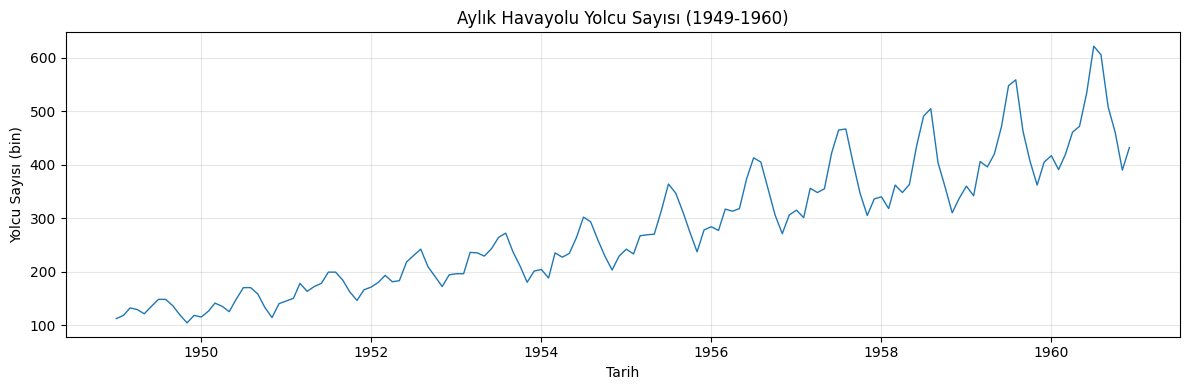


Oluşturulan veri seti boyutları:
  X_all: (132, 12)
  y_all: (132,)
  X_all (yeniden boyutlandırılmış): (132, 12, 1)

Eğitim seti boyutu: 108
Test seti boyutu: 24
Eğitim (final): 96
Doğrulama: 12

GRU Model Yapısı:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 50)                7950      
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 8001 (31.25 KB)
Trainable params: 8001 (31.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

GRU modeli eğitiliyor...
Epoch 1/200
12/12 [=========================

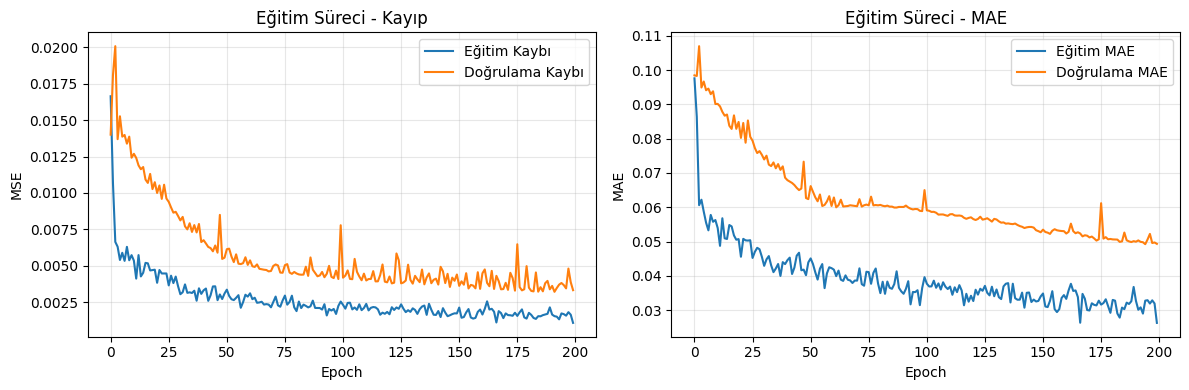


Eğitim 200 epoch sürdü.

Son model eğitiliyor (tüm eğitim verisiyle)...

GRU Eğitim Performansı:
  RMSE: 17.90
  MAE:  14.03
  MAPE: 5.73%

GRU Test Performansı:
  RMSE: 37.07
  MAE:  29.45
  MAPE: 6.38%


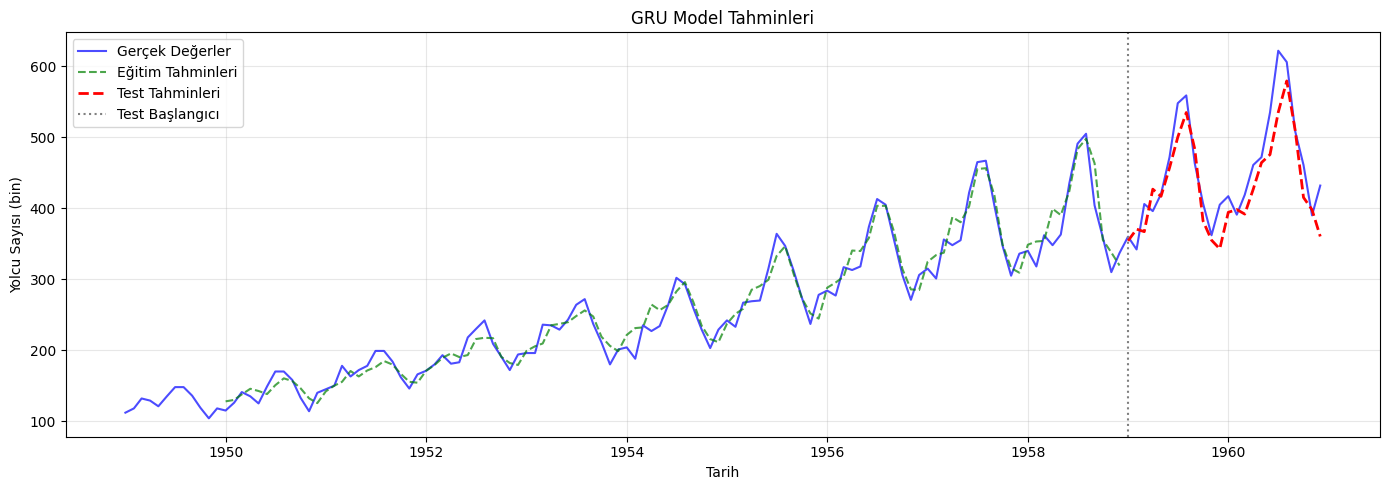


Özellik mühendisliği sonrası gözlem sayısı: 132
Özellik sayısı: 22

Kullanılan özellikler: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'rolling_std_3', 'rolling_std_12', 'seasonal_diff', 'month', 'quarter', 'year', 'year_normalized']

XGBOOST - TIMESERIESSPLIT ÇAPRAZ DOĞRULAMA

Fold 1:
  Eğitim: 22 gözlem (1950-01-01 00:00:00 - 1951-10-01 00:00:00)
  Doğrulama: 22 gözlem (1951-11-01 00:00:00 - 1953-08-01 00:00:00)
  RMSE: 31.72, MAE: 22.76, MAPE: 9.87%

Fold 2:
  Eğitim: 44 gözlem (1950-01-01 00:00:00 - 1953-08-01 00:00:00)
  Doğrulama: 22 gözlem (1953-09-01 00:00:00 - 1955-06-01 00:00:00)
  RMSE: 19.79, MAE: 15.42, MAPE: 6.43%

Fold 3:
  Eğitim: 66 gözlem (1950-01-01 00:00:00 - 1955-06-01 00:00:00)
  Doğrulama: 22 gözlem (1955-07-01 00:00:00 - 1957-04-01 00:00:00)
  RMSE: 47.49, MAE: 36.15, MAPE: 10.32%

Fold 4:
  Eğitim: 88 gözlem (1950-01-01 00:00:00 - 1957-04-

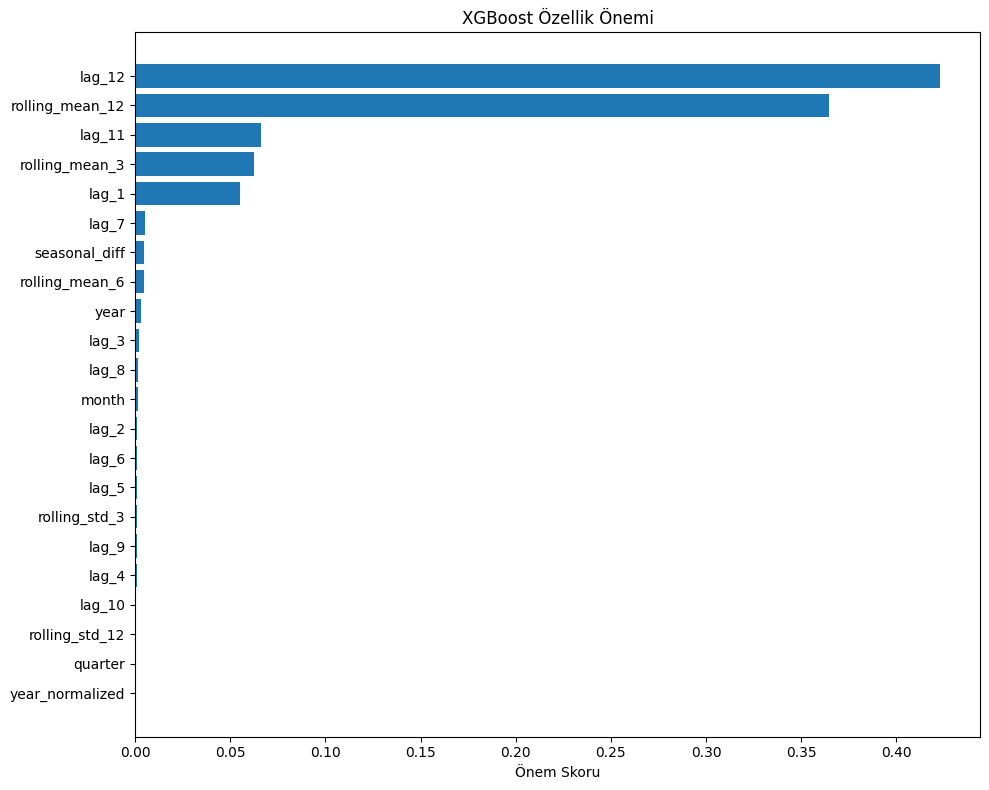


En önemli 5 özellik:
        feature  importance
          lag_1    0.055261
 rolling_mean_3    0.062465
         lag_11    0.066082
rolling_mean_12    0.364716
         lag_12    0.422904

MODEL KARŞILAŞTIRMASI (Test Seti)
Model                 RMSE        MAE       MAPE
--------------------------------------------------
GRU                  37.07      29.45      6.38%
XGBoost              55.82      43.03      8.82%


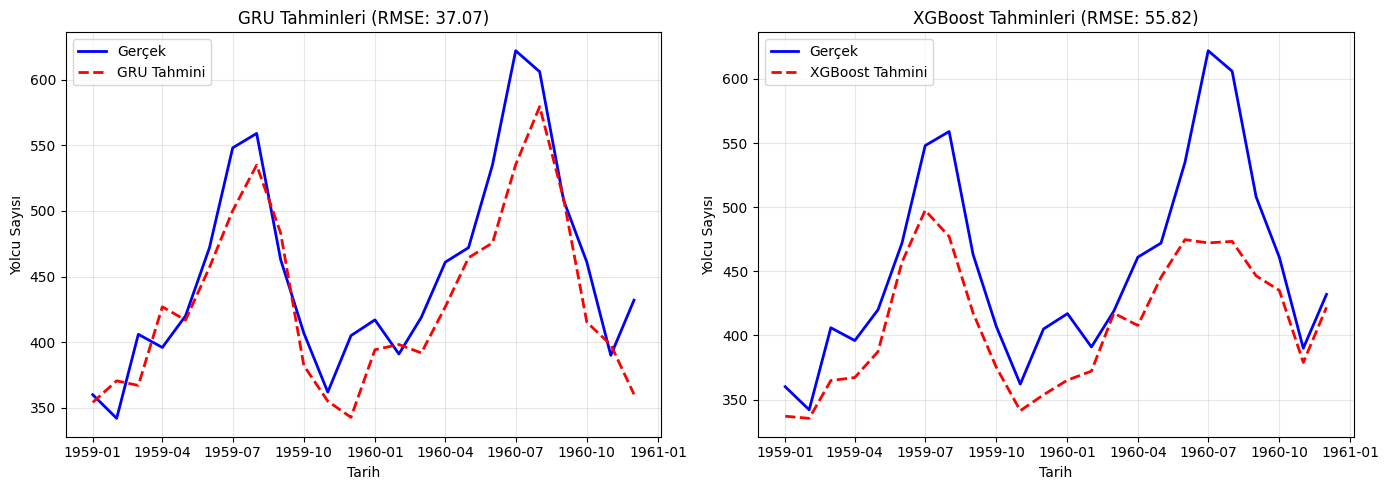


ANALİZ TAMAMLANDI

Bu çalışmada şunları yaptık:

1. AirPassengers verisini yükleyip görselleştirdik
2. GRU modeli için veriyi ölçekleyip sliding window formatına çevirdik
3. Early stopping ile GRU modelini eğittik
4. XGBoost için kapsamlı özellik mühendisliği yaptık:
   - Gecikme özellikleri (lag features)
   - Hareketli istatistikler
   - Takvim özellikleri
5. TimeSeriesSplit ile zaman-duyarlı çapraz doğrulama uyguladık
6. İki modeli karşılaştırdık

Sonuçların Yorumu:
- GRU otomatik olarak zaman bağımlılıklarını öğrenir ancak
  küçük veri setlerinde aşırı öğrenmeye eğilimlidir
- XGBoost elle çıkarılan özelliklerle çalışır, yorumlanması
  daha kolaydır ve genellikle daha stabil performans gösterir
- Her iki yöntemin de avantajları ve dezavantajları vardır;
  veri setinin büyüklüğüne ve probleme göre seçim yapılmalıdır



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import xgboost as xgb

# =============================================================
# 0) TEKRARLANABİLİRLİK İÇİN RASTGELELELIK TOHUMLARINI AYARLAMA
# =============================================================
#
# Derin öğrenme modellerinde ağırlıkların başlangıç değerleri rastgele
# atanır. Aynı kodu her çalıştırdığınızda farklı sonuçlar alırsınız.
# Bu durum sonuçların karşılaştırılmasını zorlaştırır.
#
# Tekrarlanabilirlik için tüm rastgelelik kaynaklarını kontrol altına
# almak gerekir: NumPy, TensorFlow ve Python'un kendi random modülü.

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU kullanılıyorsa deterministik işlemler için:
# tf.config.experimental.enable_op_determinism()


# =============================================================
# 1) VERİ SETİNİ YÜKLEME VE TEMEL HAZIRLIK
# =============================================================
#
# AirPassengers verisi 1949-1960 yılları arasında aylık uluslararası
# havayolu yolcu sayılarını içerir. Toplamda 144 gözlem vardır.
#
# Bu veri zaman serisi analizinde klasik bir benchmark olarak kullanılır
# çünkü hem trend hem de güçlü mevsimsellik içerir.

df = pd.read_csv('AirPassengers.csv')

# Sütun adlarını kontrol edelim
print("Veri seti sütunları:", df.columns.tolist())
print(f"Toplam gözlem sayısı: {len(df)}")

# Tarih sütununu datetime tipine çevirip indeks yapalım
# parse_dates ile okuma sırasında da yapılabilirdi ama burada
# açıkça gösteriyoruz.
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Sütun adında özel karakter varsa düzeltelim
if '#Passengers' in df.columns:
    df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# Hedef değişkeni numpy array olarak alalım
# float32 kullanıyoruz çünkü TensorFlow bu tipte daha hızlı çalışır
values = df['Passengers'].values.astype('float32').reshape(-1, 1)

# Veriye hızlı bir göz atalım
print("\nİlk 5 gözlem:")
print(df.head())
print("\nTemel istatistikler:")
print(df.describe())


# =============================================================
# 2) VERİYİ GÖRSELLEŞTİRME
# =============================================================
#
# Model kurmadan önce veriye bakmak önemlidir. Bu grafik bize:
#   - Yukarı yönlü trendin varlığını
#   - 12 aylık mevsimsel örüntüyü
#   - Varyansın zamanla arttığını (heteroskedastisite)
# gösterecektir.

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Passengers'], linewidth=1)
plt.title('Aylık Havayolu Yolcu Sayısı (1949-1960)')
plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı (bin)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Varyansın artması log dönüşümü gerektirebilir, ancak MinMaxScaler
# da bu sorunu kısmen hafifletir. İleri düzeyde çalışmalarda
# log dönüşümü tercih edilebilir.


# =============================================================
# 3) GRU İÇİN VERİ HAZIRLAMA
# =============================================================
#
# Derin öğrenme modelleri girdi değerlerinin belirli bir aralıkta
# olmasını bekler. Çok büyük veya çok küçük değerler gradyan
# hesaplamalarını bozabilir.
#
# MinMaxScaler veriyi 0-1 aralığına dönüştürür:
#   x_scaled = (x - x_min) / (x_max - x_min)
#
# Tahminler yapıldıktan sonra inverse_transform ile orijinal
# ölçeğe geri dönülür.

scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)

# ---------------------------------------------------------
# Gözetimli öğrenme formatına dönüştürme
# ---------------------------------------------------------
# Zaman serisi tahmini için veriyi şu formata çevirmemiz gerekir:
#
#   X (giriş)           →  y (çıkış)
#   [t-12, t-11, ..., t-1]  →  t
#   [t-11, t-10, ..., t]    →  t+1
#   ...
#
# Yani geçmiş 'look_back' gözleme bakarak bir sonraki değeri
# tahmin etmeye çalışıyoruz. Bu yaklaşıma "sliding window" denir.

def create_dataset(sequence, look_back=1):
    """
    Zaman serisini gözetimli öğrenme formatına dönüştürür.
    
    Parametreler:
        sequence: Ölçeklenmiş zaman serisi (2D array)
        look_back: Kaç geçmiş gözleme bakılacağı
    
    Döndürür:
        X: Giriş matrisi (n_samples, look_back)
        y: Hedef vektörü (n_samples,)
    """
    X, y = [], []
    # Not: Orijinal kodda -1 vardı, bu gereksiz bir gözlem kaybına
    # yol açıyordu. Düzeltilmiş hali:
    for i in range(len(sequence) - look_back):
        X.append(sequence[i:(i + look_back), 0])
        y.append(sequence[i + look_back, 0])
    return np.array(X), np.array(y)

# look_back = 12 seçiyoruz çünkü:
# 1) Veri aylık ve mevsimsel döngü 12 ay
# 2) Model tam bir yıllık örüntüyü görebilir
# 3) Çok uzun look_back parametre sayısını artırır ve aşırı öğrenmeye
#    yol açabilir
look_back = 12

X_all, y_all = create_dataset(values_scaled, look_back)

print(f"\nOluşturulan veri seti boyutları:")
print(f"  X_all: {X_all.shape}")  # (132, 12) olmalı
print(f"  y_all: {y_all.shape}")  # (132,) olmalı

# ---------------------------------------------------------
# GRU giriş formatı
# ---------------------------------------------------------
# Keras'taki RNN katmanları 3 boyutlu giriş bekler:
#   (batch_size, timesteps, features)
#
# Bizim durumumuzda:
#   - batch_size: Eğitim sırasında belirlenir
#   - timesteps: look_back = 12
#   - features: 1 (sadece yolcu sayısı)
#
# Eğer birden fazla değişken olsaydı (örneğin hava durumu, tatil
# bilgisi) features sayısı artardı.

X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)
print(f"  X_all (yeniden boyutlandırılmış): {X_all.shape}")

# ---------------------------------------------------------
# Eğitim / Test ayrımı
# ---------------------------------------------------------
# Zaman serilerinde rastgele bölme YAPILMAZ çünkü bu gelecekten
# geçmişe bilgi sızıntısına yol açar. Bunun yerine kronolojik
# sıra korunur: ilk kısım eğitim, son kısım test.
#
# Genellikle %70-80 eğitim, %20-30 test kullanılır.
# 132 gözlemde ~26 gözlemi (%20) test için ayıralım.

test_size = 24  # Son 2 yıl (24 ay) test için
train_size = X_all.shape[0] - test_size

X_train, X_test = X_all[:train_size], X_all[train_size:]
y_train, y_test = y_all[:train_size], y_all[train_size:]

print(f"\nEğitim seti boyutu: {X_train.shape[0]}")
print(f"Test seti boyutu: {X_test.shape[0]}")

# Eğitim setinden bir kısmını doğrulama (validation) için ayıralım
# Bu, eğitim sırasında aşırı öğrenmeyi izlememize yarar
val_size = 12  # Son 1 yıl doğrulama için
X_train_final = X_train[:-val_size]
X_val = X_train[-val_size:]
y_train_final = y_train[:-val_size]
y_val = y_train[-val_size:]

print(f"Eğitim (final): {X_train_final.shape[0]}")
print(f"Doğrulama: {X_val.shape[0]}")


# =============================================================
# 4) GRU MODELİNİN KURULMASI
# =============================================================
#
# GRU (Gated Recurrent Unit) bir tür tekrarlayan sinir ağıdır (RNN).
# Standart RNN'lerin "uzun vadeli bağımlılıkları öğrenememe" sorununu
# çözmek için tasarlanmıştır.
#
# GRU'nun LSTM'den farkı daha az parametre içermesidir:
#   - LSTM: 3 kapı (forget, input, output) + hücre durumu
#   - GRU: 2 kapı (reset, update) + gizli durum
#
# Daha az parametre = daha hızlı eğitim, daha az aşırı öğrenme riski
# Küçük veri setlerinde GRU genellikle LSTM kadar iyi veya daha iyi
# performans gösterir.

def build_gru_model(look_back, units=50, dropout_rate=0.2):
    """
    GRU tabanlı zaman serisi tahmin modeli oluşturur.
    
    Parametreler:
        look_back: Giriş zaman adımı sayısı
        units: GRU katmanındaki nöron sayısı
        dropout_rate: Aşırı öğrenmeyi önlemek için dropout oranı
    """
    model = Sequential([
        # GRU katmanı
        # units: Gizli durumun boyutu (ne kadar "hafıza" tutulacağı)
        # input_shape: (zaman adımları, özellik sayısı)
        GRU(units, input_shape=(look_back, 1), return_sequences=False),
        
        # Dropout: Eğitim sırasında rastgele nöronları kapatarak
        # aşırı öğrenmeyi önler
        Dropout(dropout_rate),
        
        # Çıkış katmanı: Tek bir değer tahmin ediyoruz
        Dense(1)
    ])
    
    # Modeli derleme
    # loss: Optimize edilecek kayıp fonksiyonu
    # optimizer: Ağırlık güncelleme algoritması
    # metrics: Eğitim sırasında izlenecek ek metrikler
    model.compile(
        loss='mean_squared_error',
        optimizer='adam',
        metrics=['mae']  # Mean Absolute Error de izleyelim
    )
    
    return model

model_gru = build_gru_model(look_back, units=50, dropout_rate=0.2)

# Model özetini görelim
print("\nGRU Model Yapısı:")
model_gru.summary()

# Parametre sayısı hesabı (GRU için):
# GRU parametreleri = 3 * [(input_dim + 1) * units + units * units]
# Bizim durumumuzda: 3 * [(1 + 1) * 50 + 50 * 50] = 3 * [100 + 2500] = 7800
# Dense parametreleri: units * output_dim + output_dim = 50 * 1 + 1 = 51
# Toplam: ~7851 parametre


# =============================================================
# 5) GRU MODELİNİN EĞİTİLMESİ
# =============================================================
#
# Eğitim sürecinde dikkat edilmesi gerekenler:
#
# epochs: Tüm eğitim verisinin model üzerinden kaç kez geçtiği.
#   - Çok az → model yeterince öğrenemez (underfitting)
#   - Çok fazla → model ezberlemeye başlar (overfitting)
#   - Early stopping ile optimal nokta otomatik bulunabilir
#
# batch_size: Her gradyan güncellemesinde kaç örneğin kullanıldığı.
#   - batch_size=1: Stokastik gradyan inişi, çok gürültülü
#   - batch_size=n (tüm veri): Batch gradyan inişi, yavaş
#   - batch_size=16-64: Mini-batch, genellikle iyi denge sağlar
#
# Küçük veri setlerinde batch_size küçük tutulmalı (8-16 gibi).

# Early stopping callback'i
# Doğrulama kaybı 'patience' epoch boyunca iyileşmezse eğitimi durdurur
# restore_best_weights: En iyi modeli geri yükler
early_stop = EarlyStopping(
    monitor='val_loss',      # İzlenecek metrik
    patience=15,             # Kaç epoch sabırlı olunacak
    restore_best_weights=True,
    verbose=1
)

print("\nGRU modeli eğitiliyor...")
history = model_gru.fit(
    X_train_final, y_train_final,
    epochs=200,              # Maksimum epoch (early stopping durduracak)
    batch_size=8,            # Mini-batch boyutu
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------------------------------------
# Eğitim sürecinin görselleştirilmesi
# ---------------------------------------------------------
# Bu grafik modelin öğrenip öğrenemediğini ve aşırı öğrenme
# olup olmadığını gösterir.
#
# İdeal durum: Eğitim ve doğrulama kayıpları birlikte düşer
# Aşırı öğrenme: Eğitim kaybı düşerken doğrulama kaybı artar

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Eğitim Süreci - Kayıp')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Eğitim MAE')
plt.plot(history.history['val_mae'], label='Doğrulama MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Eğitim Süreci - MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEğitim {len(history.history['loss'])} epoch sürdü.")


# =============================================================
# 6) GRU İLE TAHMİN VE PERFORMANS DEĞERLENDİRMESİ
# =============================================================

# Tüm eğitim verisiyle modeli yeniden eğitelim (doğrulama seti dahil)
# Bu son model ile test tahminleri yapacağız
print("\nSon model eğitiliyor (tüm eğitim verisiyle)...")
model_gru_final = build_gru_model(look_back, units=50, dropout_rate=0.2)
model_gru_final.fit(
    X_train, y_train,
    epochs=len(history.history['loss']),  # Optimal epoch sayısı
    batch_size=8,
    verbose=0
)

# Tahminler
train_pred = model_gru_final.predict(X_train, verbose=0)
test_pred = model_gru_final.predict(X_test, verbose=0)

# Tahminleri orijinal ölçeğe dönüştürme
# scaler.inverse_transform 2D array bekler
train_pred_inv = scaler.inverse_transform(train_pred)
test_pred_inv = scaler.inverse_transform(test_pred)

y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# ---------------------------------------------------------
# Performans metrikleri
# ---------------------------------------------------------
# RMSE (Root Mean Squared Error): Büyük hataları daha çok cezalandırır
# MAE (Mean Absolute Error): Tüm hatalara eşit ağırlık verir
# MAPE (Mean Absolute Percentage Error): Yüzde cinsinden hata

def calculate_metrics(y_true, y_pred, set_name=""):
    """Tahmin performans metriklerini hesaplar ve yazdırır."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name} Performansı:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return rmse, mae, mape

rmse_train, mae_train, mape_train = calculate_metrics(
    y_train_inv.flatten(), train_pred_inv.flatten(), "GRU Eğitim"
)
rmse_test, mae_test, mape_test = calculate_metrics(
    y_test_inv.flatten(), test_pred_inv.flatten(), "GRU Test"
)

# ---------------------------------------------------------
# Tahmin grafiği
# ---------------------------------------------------------
# Grafik için doğru tarih indekslerini oluşturmamız gerekiyor
# create_dataset fonksiyonu ilk look_back gözlemi "harcar"

# Eğitim tahminleri için tarihler
train_dates = df.index[look_back:look_back + len(y_train_inv)]
# Test tahminleri için tarihler
test_dates = df.index[look_back + len(y_train_inv):]

plt.figure(figsize=(14, 5))

# Tüm gerçek değerler
plt.plot(df.index, df['Passengers'], 'b-', label='Gerçek Değerler', alpha=0.7)

# Eğitim tahminleri
plt.plot(train_dates, train_pred_inv, 'g--', label='Eğitim Tahminleri', alpha=0.7)

# Test tahminleri
plt.plot(test_dates, test_pred_inv, 'r--', label='Test Tahminleri', linewidth=2)

# Test dönemini vurgulama
plt.axvline(x=test_dates[0], color='gray', linestyle=':', label='Test Başlangıcı')

plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı (bin)')
plt.title('GRU Model Tahminleri')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =============================================================
# 7) XGBOOST İÇİN ÖZELLİK MÜHENDİSLİĞİ
# =============================================================
#
# Ağaç tabanlı modeller (XGBoost, Random Forest) zaman serisinin
# doğrudan kendisini alamaz. Bunun yerine elle özellik çıkarmamız
# gerekir. Bu özelliklere "lag features" denir.
#
# Ayrıca mevsimselliği yakalamak için takvim özellikleri de ekleriz:
#   - Ay numarası (1-12)
#   - Çeyrek (1-4)
#   - Yılın hangi günü (1-365)
#
# Daha gelişmiş özellikler:
#   - Hareketli ortalamalar
#   - Hareketli standart sapma (volatilite)
#   - Mevsimsel farklar (y_t - y_{t-12})

df_features = df.copy()

# ---------------------------------------------------------
# Gecikme (lag) özellikleri
# ---------------------------------------------------------
# Geçmiş değerleri özellik olarak ekliyoruz

for lag in range(1, 13):  # 1'den 12'ye kadar gecikmeler
    df_features[f'lag_{lag}'] = df_features['Passengers'].shift(lag)

# ---------------------------------------------------------
# Hareketli istatistikler
# ---------------------------------------------------------
# Son n dönemin ortalaması, trendi yakalar
# Son n dönemin standart sapması, volatiliteyi yakalar

df_features['rolling_mean_3'] = df_features['Passengers'].shift(1).rolling(window=3).mean()
df_features['rolling_mean_6'] = df_features['Passengers'].shift(1).rolling(window=6).mean()
df_features['rolling_mean_12'] = df_features['Passengers'].shift(1).rolling(window=12).mean()

df_features['rolling_std_3'] = df_features['Passengers'].shift(1).rolling(window=3).std()
df_features['rolling_std_12'] = df_features['Passengers'].shift(1).rolling(window=12).std()

# ---------------------------------------------------------
# Mevsimsel fark
# ---------------------------------------------------------
# Bir önceki yılın aynı ayına göre değişim

df_features['seasonal_diff'] = df_features['Passengers'] - df_features['Passengers'].shift(12)

# ---------------------------------------------------------
# Takvim özellikleri
# ---------------------------------------------------------

df_features['month'] = df_features.index.month
df_features['quarter'] = df_features.index.quarter
df_features['year'] = df_features.index.year

# Yılı normalize edelim (trend bilgisi olarak)
df_features['year_normalized'] = (df_features['year'] - df_features['year'].min()) / \
                                  (df_features['year'].max() - df_features['year'].min())

# ---------------------------------------------------------
# Eksik değerleri temizleme
# ---------------------------------------------------------
# Gecikme ve hareketli ortalamalar nedeniyle ilk satırlarda NaN oluşur

df_features = df_features.dropna()
print(f"\nÖzellik mühendisliği sonrası gözlem sayısı: {len(df_features)}")
print(f"Özellik sayısı: {len(df_features.columns) - 1}")  # Passengers hariç

# Özellik listesi
feature_cols = [col for col in df_features.columns if col != 'Passengers']
print(f"\nKullanılan özellikler: {feature_cols}")

X = df_features[feature_cols]
y = df_features['Passengers']


# =============================================================
# 8) TİMESERIESSPLIT İLE ÇAPRAZ DOĞRULAMA
# =============================================================
#
# Standart k-fold çapraz doğrulama zaman serilerinde KULLANILMAZ
# çünkü verinin rastgele karıştırılması kronolojik sırayı bozar
# ve gelecekten geçmişe bilgi sızıntısına yol açar.
#
# TimeSeriesSplit bu sorunu çözer:
#
# Fold 1: Eğitim [----]     | Doğrulama [--]
# Fold 2: Eğitim [------]   | Doğrulama [--]
# Fold 3: Eğitim [--------] | Doğrulama [--]
# ...
#
# Her fold'da eğitim seti büyür, doğrulama seti hep "gelecekte" kalır.

tscv = TimeSeriesSplit(n_splits=5)

# Sonuçları saklamak için listeler
rmse_list = []
mae_list = []
mape_list = []

print("\n" + "=" * 50)
print("XGBOOST - TIMESERIESSPLIT ÇAPRAZ DOĞRULAMA")
print("=" * 50)

fold = 1
for train_index, val_index in tscv.split(X):
    # Eğitim ve doğrulama kümelerini ayır
    X_tr, X_val = X.iloc[train_index], X.iloc[val_index]
    y_tr, y_val = y.iloc[train_index], y.iloc[val_index]
    
    print(f"\nFold {fold}:")
    print(f"  Eğitim: {len(X_tr)} gözlem ({y_tr.index.min()} - {y_tr.index.max()})")
    print(f"  Doğrulama: {len(X_val)} gözlem ({y_val.index.min()} - {y_val.index.max()})")
    
    # XGBoost modeli
    # n_estimators: Ağaç sayısı
    # learning_rate: Öğrenme hızı (küçük = daha yavaş ama daha stabil)
    # max_depth: Ağaç derinliği (derin = daha karmaşık model)
    # early_stopping_rounds: Aşırı öğrenmeyi önler
    model_xgb = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        early_stopping_rounds=30
    )
    
    # Modeli eğit (early stopping için eval_set gerekli)
    model_xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Tahmin
    y_val_pred = model_xgb.predict(X_val)
    
    # Metrikler
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae = mean_absolute_error(y_val, y_val_pred)
    mape = np.mean(np.abs((y_val - y_val_pred) / y_val)) * 100
    
    rmse_list.append(rmse)
    mae_list.append(mae)
    mape_list.append(mape)
    
    print(f"  RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")
    
    fold += 1

# Ortalama sonuçlar
print("\n" + "-" * 50)
print("ÇAPRAZ DOĞRULAMA SONUÇLARI (Ortalama ± Std)")
print("-" * 50)
print(f"RMSE: {np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}")
print(f"MAE:  {np.mean(mae_list):.2f} ± {np.std(mae_list):.2f}")
print(f"MAPE: {np.mean(mape_list):.2f}% ± {np.std(mape_list):.2f}%")


# =============================================================
# 9) SON XGBOOST MODELİ VE ÖZELLİK ÖNEMİ
# =============================================================
#
# Çapraz doğrulama performans tahminini verir.
# Şimdi tüm veriyle son modeli eğitip özellik önemini inceleyelim.

# Son 24 gözlemi test için ayır
train_end = len(X) - 24
X_train_xgb = X.iloc[:train_end]
X_test_xgb = X.iloc[train_end:]
y_train_xgb = y.iloc[:train_end]
y_test_xgb = y.iloc[train_end:]

# Son model
final_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED
)
final_xgb.fit(X_train_xgb, y_train_xgb)

# Test tahminleri
y_test_pred_xgb = final_xgb.predict(X_test_xgb)

print("\n" + "=" * 50)
print("XGBOOST TEST PERFORMANSI")
print("=" * 50)
calculate_metrics(y_test_xgb.values, y_test_pred_xgb, "XGBoost Test")

# ---------------------------------------------------------
# Özellik önemi grafiği
# ---------------------------------------------------------
# Hangi özelliklerin tahmine en çok katkı sağladığını gösterir
# Bu bilgi hem model yorumlama hem de özellik seçimi için faydalıdır

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_xgb.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Önem Skoru')
plt.title('XGBoost Özellik Önemi')
plt.tight_layout()
plt.show()

# En önemli 5 özellik
print("\nEn önemli 5 özellik:")
print(feature_importance.tail(5).to_string(index=False))


# =============================================================
# 10) MODEL KARŞILAŞTIRMASI VE SONUÇ
# =============================================================

print("\n" + "=" * 50)
print("MODEL KARŞILAŞTIRMASI (Test Seti)")
print("=" * 50)
print(f"{'Model':<15} {'RMSE':>10} {'MAE':>10} {'MAPE':>10}")
print("-" * 50)
print(f"{'GRU':<15} {rmse_test:>10.2f} {mae_test:>10.2f} {mape_test:>9.2f}%")

xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, y_test_pred_xgb))
xgb_mae = mean_absolute_error(y_test_xgb, y_test_pred_xgb)
xgb_mape = np.mean(np.abs((y_test_xgb - y_test_pred_xgb) / y_test_xgb)) * 100
print(f"{'XGBoost':<15} {xgb_rmse:>10.2f} {xgb_mae:>10.2f} {xgb_mape:>9.2f}%")

# Karşılaştırma grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRU tahminleri
axes[0].plot(test_dates, y_test_inv, 'b-', label='Gerçek', linewidth=2)
axes[0].plot(test_dates, test_pred_inv, 'r--', label='GRU Tahmini', linewidth=2)
axes[0].set_title(f'GRU Tahminleri (RMSE: {rmse_test:.2f})')
axes[0].set_xlabel('Tarih')
axes[0].set_ylabel('Yolcu Sayısı')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XGBoost tahminleri
axes[1].plot(y_test_xgb.index, y_test_xgb.values, 'b-', label='Gerçek', linewidth=2)
axes[1].plot(y_test_xgb.index, y_test_pred_xgb, 'r--', label='XGBoost Tahmini', linewidth=2)
axes[1].set_title(f'XGBoost Tahminleri (RMSE: {xgb_rmse:.2f})')
axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Yolcu Sayısı')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("ANALİZ TAMAMLANDI")
print("=" * 50)
print("""
Bu çalışmada şunları yaptık:

1. AirPassengers verisini yükleyip görselleştirdik
2. GRU modeli için veriyi ölçekleyip sliding window formatına çevirdik
3. Early stopping ile GRU modelini eğittik
4. XGBoost için kapsamlı özellik mühendisliği yaptık:
   - Gecikme özellikleri (lag features)
   - Hareketli istatistikler
   - Takvim özellikleri
5. TimeSeriesSplit ile zaman-duyarlı çapraz doğrulama uyguladık
6. İki modeli karşılaştırdık

Sonuçların Yorumu:
- GRU otomatik olarak zaman bağımlılıklarını öğrenir ancak
  küçük veri setlerinde aşırı öğrenmeye eğilimlidir
- XGBoost elle çıkarılan özelliklerle çalışır, yorumlanması
  daha kolaydır ve genellikle daha stabil performans gösterir
- Her iki yöntemin de avantajları ve dezavantajları vardır;
  veri setinin büyüklüğüne ve probleme göre seçim yapılmalıdır
""")